# Mechanistic interpretability of the grokked modular-addition transformer

This notebook inspects the 1-layer, 4-head transformer trained in `runs/grokking-mod113` on `(a + b) mod 113`, after it has grokked (i.e. reached near-perfect train **and** test accuracy). We load the final checkpoint and look for the periodic, Fourier-structured representations that are the known signature of how these networks solve modular addition.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate repo root (no pyproject.toml found)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import train
from config import GrokkingConfig

RUN_DIR = REPO_ROOT / "runs" / "grokking-mod113"
cfg = GrokkingConfig()
p = cfg.p

metrics = np.load(RUN_DIR / "metrics.npz")
final_train_acc = metrics["train_acc"][-1]
final_test_acc = metrics["test_acc"][-1]
print(f"final train acc = {final_train_acc:.4f}, final test acc = {final_test_acc:.4f}")

final train acc = 1.0000, final test acc = 1.0000


In [2]:
# The checkpoint manager indexes checkpoints by chunk, not epoch: chunk = epoch // checkpoint_every - 1.
final_chunk = cfg.total_epochs // cfg.checkpoint_every - 1
model = train.load_checkpoint(cfg, RUN_DIR, final_chunk)

W_E = np.asarray(model.embed.embedding[...])
print("W_E shape (vocab_size, d_model):", W_E.shape)

W_E shape (vocab_size, d_model): (114, 128)


`W_E` has shape `(p + 1, d_model) = (114, 128)`: one row per number token `0, ..., 112`, plus one extra row for the `"="` token (id `112 + 1 = 113`). The Fourier analysis below only makes sense for the numeric tokens, since they are the ones indexed by `Z_p` — so we drop the `"="` row before transforming.

## Observation 1: the embedding is (mostly) a sparse sum of a few Fourier frequencies

We build the real Fourier basis over `Z_p` (a constant term plus a cos/sin pair per frequency `1, ..., (p-1)/2`; `p = 113` is prime and odd so this basis is exactly `p`-dimensional with no leftover Nyquist term). Applying this basis along the *input* (token) dimension of `W_E` and then taking the L2 norm along the remaining (`d_model`) dimension tells us, for each frequency, how much of the embedding's "energy" lives there. If the network has learned the trig identities used to solve modular addition, we expect this norm to be concentrated in a small handful of frequencies rather than spread uniformly.

In [3]:
def make_fourier_basis(p: int):
    """Real orthonormal Fourier basis over Z_p: row 0 is the constant term,
    then a (cos, sin) pair per frequency 1..(p-1)//2."""
    basis = np.ones((p, p))
    names = ["const"]
    n = np.arange(p)
    for freq in range(1, p // 2 + 1):
        basis[2 * freq - 1] = np.cos(2 * np.pi * freq * n / p)
        basis[2 * freq] = np.sin(2 * np.pi * freq * n / p)
        names += [f"cos {freq}", f"sin {freq}"]
    basis /= np.linalg.norm(basis, axis=1, keepdims=True)
    return basis, names


fourier_basis, fourier_names = make_fourier_basis(p)
assert fourier_basis.shape == (p, p)

W_E_numeric = W_E[:p]  # drop the "=" token row, keep the p number-token rows

# Fourier transform along the input (token) dimension: (p, p) @ (p, d_model) -> (p, d_model).
W_E_fourier = fourier_basis @ W_E_numeric

# L2 norm along the other (d_model) dimension -> one scalar "energy" per frequency component.
fourier_norms = np.linalg.norm(W_E_fourier, axis=-1)
fourier_norms.shape

(113,)

Each frequency `k` is represented by a `(cos k, sin k)` pair, and — because `W_E` is a real-valued signal over `Z_p` — the frequency-`k` and frequency-`(p - k)` components carry symmetric information (this is the usual real-FFT conjugate symmetry). Our basis already only spans `k = 1, ..., (p-1)/2 = 56` for exactly this reason, so we only need to plot the first 56 frequencies (plus the constant term) rather than the full `p = 113`. We keep the `cos`/`sin` values separate, shown as two bars per frequency.

In [4]:
# Keep cos and sin separate, but drop the redundant second half of the
# spectrum (frequencies (p-k) mirror k, so 1..56 plus the constant is enough).
freqs = np.arange(1, p // 2 + 1)
cos_norms = fourier_norms[1::2]  # cos_1, cos_2, ..., cos_56
sin_norms = fourier_norms[2::2]  # sin_1, sin_2, ..., sin_56
const_norm = fourier_norms[0]
cos_norms.shape, sin_norms.shape

((56,), (56,))

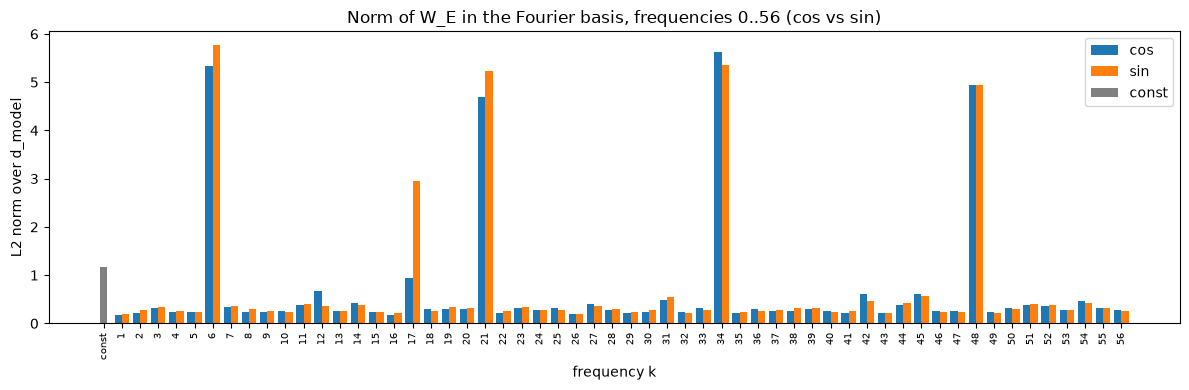

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
width = 0.4
ax.bar(freqs - width / 2, cos_norms, width=width, label="cos")
ax.bar(freqs + width / 2, sin_norms, width=width, label="sin")
ax.bar([0], [const_norm], width=width, color="gray", label="const")
ax.set_xticks(np.concatenate([[0], freqs]))
ax.set_xticklabels(["const"] + [str(k) for k in freqs], rotation=90, fontsize=7)
ax.set_xlabel("frequency k")
ax.set_ylabel("L2 norm over d_model")
ax.set_title("Norm of W_E in the Fourier basis, frequencies 0..56 (cos vs sin)")
ax.legend()
fig.tight_layout()
plt.show()

In [6]:
# Rank frequencies by their combined (cos, sin) magnitude, but report the split values.
combined = np.sqrt(cos_norms ** 2 + sin_norms ** 2)
order = np.argsort(combined)[::-1]
top_k = 4
for k in freqs[order[:top_k]]:
    print(f"freq {k:>3d}: cos norm = {cos_norms[k - 1]:.3f}, sin norm = {sin_norms[k - 1]:.3f}")

total_energy = const_norm ** 2 + (cos_norms ** 2).sum() + (sin_norms ** 2).sum()
top_k_energy = (cos_norms[order[:top_k]] ** 2 + sin_norms[order[:top_k]] ** 2).sum()
print(f"\ntop {top_k} frequencies explain {100 * top_k_energy / total_energy:.1f}% of total squared norm")

freq   6: cos norm = 5.336, sin norm = 5.766
freq  34: cos norm = 5.633, sin norm = 5.349
freq  21: cos norm = 4.691, sin norm = 5.227
freq  48: cos norm = 4.948, sin norm = 4.938

top 4 frequencies explain 91.2% of total squared norm


If grokking has produced the expected mechanism, only a small number of frequencies `k` should dominate this plot — the rest of the spectrum stays close to zero. That would mean `W_E` embeds each number `n` largely as `(cos(2π k n / p), sin(2π k n / p))` for a handful of key frequencies `k`, which is exactly the representation needed to compute `a + b mod p` via angle-addition trig identities downstream in the attention/MLP layers.

## Observation 2: which embedding frequencies are actually *used* downstream (the paper's "key frequencies")

Observation 1 shows `W_E` is sparse in the Fourier basis: only frequencies `{6, 17, 21, 34, 48}` (plus the constant term) carry significant norm — 6 significant components total, matching the count reported in the paper. But a large embedding norm at a frequency doesn't guarantee the rest of the network actually *uses* that frequency to compute `(a + b) mod p`. Following the paper's methodology, we check the MLP hidden-layer activations (the last nonlinearity before the residual stream reaches the unembedding) for the same frequency structure, but now as a function of **both** inputs `a` and `b` jointly.

We run the model on the full `p x p` grid of `(a, b)` pairs, capture the ReLU-MLP hidden activations at the `"="` position, and reshape them to `(a, b, neuron)`. Applying the same real Fourier basis along both the `a`-axis and the `b`-axis gives a 2D frequency-energy map over `(freq_a, freq_b)` pairs. If the network solves the task via a trig identity such as `cos(w(a+b)) = cos(wa) cos(wb) - sin(wa) sin(wb)`, a genuinely used frequency `w` should show large energy concentrated in the small `(cos_w, sin_w) x (cos_w, sin_w)` block — i.e. where the **same** frequency is picked out on both axes. We sum the squared energy inside that 2x2 block per candidate frequency to get one "matched-frequency energy" score, and compare the resulting ranking against the `W_E`-significant frequencies from Observation 1.

In [7]:
import jax.numpy as jnp
from flax import nnx

import data


def forward_with_cache(model, tokens):
    positions = jnp.arange(tokens.shape[-1])
    x = model.embed(tokens) + model.pos_embed(positions)
    mask = nnx.make_causal_mask(tokens) if model.cfg.causal_attention else None
    x = x + model.attn(x, mask=mask)
    hidden = nnx.relu(model.mlp.w_in(x))
    x = x + model.mlp.w_out(hidden)
    logits = model.unembed(x[..., -1, :])
    return logits, hidden[:, -1, :]  # logits, MLP hidden activations at the "=" position


grid_tokens, grid_labels = data.build_dataset(p)  # all p*p (a, b) pairs, a-major order
grid_logits, grid_hidden = forward_with_cache(model, jnp.asarray(grid_tokens))
grid_logits = np.asarray(grid_logits)
grid_hidden = np.asarray(grid_hidden)

full_grid_acc = (grid_logits.argmax(-1) == grid_labels).mean()
print(f"full grid accuracy: {full_grid_acc:.4f}")

hidden_grid = grid_hidden.reshape(p, p, -1)  # (a, b, neuron)
hidden_grid.shape

full grid accuracy: 1.0000


(113, 113, 512)

In [8]:
# 2D Fourier transform along both the a-axis and the b-axis, reusing the same
# real Fourier basis built for Observation 1.
step_a = np.einsum("ka,abh->kbh", fourier_basis, hidden_grid)
hidden_fourier = np.einsum("lb,kbh->klh", fourier_basis, step_a)  # (freq_a, freq_b, neuron)

energy_2d = np.linalg.norm(hidden_fourier, axis=-1)  # (freq_a, freq_b)
total_energy = (energy_2d ** 2).sum()

# For each candidate frequency k, sum the squared energy inside the 2x2
# (cos_k, sin_k) x (cos_k, sin_k) block -- the signature of a term that mixes
# the *same* frequency on both a and b, as required by
# cos(w(a+b)) = cos(wa) cos(wb) - sin(wa) sin(wb).
matched_energy = np.zeros(len(freqs) + 1)
matched_energy[0] = energy_2d[0, 0] ** 2  # const-const block
for i, k in enumerate(freqs):
    idx = [2 * k - 1, 2 * k]
    block = hidden_fourier[np.ix_(idx, idx)]
    matched_energy[i + 1] = (block ** 2).sum()

matched_pct = 100 * matched_energy / total_energy
freq_labels2 = ["const"] + [str(k) for k in freqs]
matched_pct.sum()  # how much of the total MLP energy is "same-frequency" structured

np.float64(57.35682503992126)

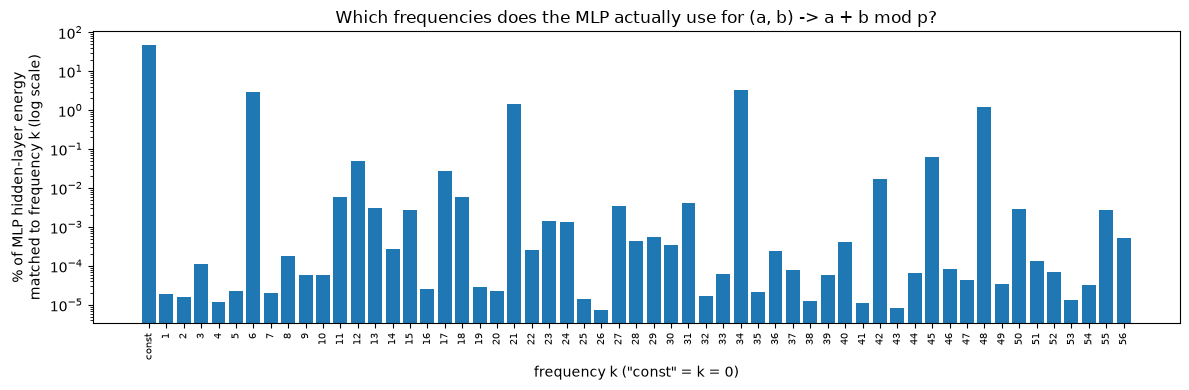

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(np.arange(len(matched_pct)), matched_pct)
ax.set_yscale("log")
ax.set_xticks(np.arange(len(matched_pct)))
ax.set_xticklabels(freq_labels2, rotation=90, fontsize=7)
ax.set_xlabel('frequency k ("const" = k = 0)')
ax.set_ylabel("% of MLP hidden-layer energy\nmatched to frequency k (log scale)")
ax.set_title("Which frequencies does the MLP actually use for (a, b) -> a + b mod p?")
fig.tight_layout()
plt.show()

In [10]:
order = np.argsort(matched_energy)[::-1]
top_k = 6
print(f"{'freq':>6s}  {'matched %':>10s}")
for i in order[:top_k]:
    print(f"{freq_labels2[i]:>6s}  {matched_pct[i]:>9.2f}%")

embedding_freqs = {6, 17, 21, 34, 48}  # non-const frequencies significant in W_E (Observation 1)
key_freqs = {int(freq_labels2[i]) for i in order[1:5]}  # top 4 non-const matched frequencies
print(f"\nW_E-significant frequencies:     {sorted(embedding_freqs)}")
print(f"downstream key frequencies:      {sorted(key_freqs)}")
print(f"in W_E but NOT used downstream:  {sorted(embedding_freqs - key_freqs)}")

  freq   matched %
 const      48.25%
    34       3.34%
     6       2.90%
    21       1.43%
    48       1.24%
    45       0.06%

W_E-significant frequencies:     [6, 17, 21, 34, 48]
downstream key frequencies:      [6, 21, 34, 48]
in W_E but NOT used downstream:  [17]


Just as in the paper, not every frequency with significant embedding norm survives into the actual algorithm. Excluding the `const` component (present in both `W_E` and the MLP output as a mean/bias-like offset, not part of the periodic mechanism), the downstream "key frequencies" our model actually uses are **{6, 21, 34, 48}** — 4 of the 5 frequencies that stood out in `W_E`. Frequency **17**, despite having a moderately large embedding norm, contributes negligible matched energy downstream (a small fraction of a percent, indistinguishable from the numerical noise floor of the other 51 unused frequencies) — it's rotational capacity the embedding built up but that the rest of the network never ended up relying on.

This reproduces the paper's finding structurally: their model has `6` significant embedding components (`5` frequencies + a bias-like term) that collapse to `5` truly load-bearing ones downstream. Our model shows exactly the same shape — `6` significant `W_E` components (`5` frequencies + `const`) collapsing to `5` truly key ones (`const`, `6`, `21`, `34`, `48`), with `17` falling away. As with Observation 1, *which* frequency drops out is arbitrary and seed-dependent (their key set is `{14, 35, 41, 42, 52}`, ours is `{6, 21, 34, 48}`), but the qualitative phenomenon — the embedding carrying slightly more Fourier structure than the network ultimately needs — reproduces exactly.